# 🚚 07 - Project Summary for Presentation

# Sistema de análisis y predicción de riesgo operacional logístico

## Resumen ejecutivo final del proyecto

### Integrantes
- Maicol Hernández

---

# Objetivo del proyecto

Desarrollar un sistema de análisis y predicción de riesgo operacional utilizando técnicas de Machine Learning aplicadas a operaciones logísticas.

El objetivo principal fue identificar operaciones críticas antes de que ocurran problemas reales.

---

# Problema de negocio

Las operaciones logísticas presentan múltiples factores de riesgo:

- sobrecarga de vehículos;
- rutas extensas;
- velocidades elevadas;
- utilización excesiva de capacidad;
- vehículos altamente exigidos.

Estas situaciones pueden provocar:

- incidencias;
- retrasos;
- desgaste operacional;
- aumento del riesgo logístico.


# 📦 1. Construcción del dataset

Para el proyecto se integraron distintos datasets logísticos:

- `envios.csv`
- `rutas.csv`
- `vehiculos.csv`
- `incidencias.csv`

---

## Resultado final

Después del proceso de integración y transformación se construyó:

# `dataset_modelo_v3.csv`


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,5)

df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print(df.shape)

df.head()


(998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,...,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,...,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,...,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,...,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,...,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,...,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


# 🧹 2. Limpieza y transformación de datos

Durante esta etapa se realizaron:

- tratamiento de valores nulos;
- manejo de outliers;
- feature engineering;
- transformaciones logarítmicas.

Esto permitió estabilizar los datos y mejorar el aprendizaje de los modelos.


# 📈 3. Transformaciones logarítmicas

Durante el feature engineering se aplicaron transformaciones logarítmicas a variables con distribuciones altamente asimétricas o con presencia de valores extremos.

## Variables transformadas

- `peso_kg_log`
- `distancia_km_log`
- `volumen_m3_log`
- `velocidad_promedio_km_h_log`
- `densidad_carga_log`
- `riesgo_velocidad_log`
- `km_recorridos_log`

---

## Objetivo de la transformación

Las transformaciones logarítmicas permitieron:

- reducir asimetrías;
- disminuir impacto de outliers;
- estabilizar distribuciones;
- mejorar separación de patrones;
- facilitar el aprendizaje de los modelos.

Esto fue especialmente importante en variables relacionadas con:

- distancia;
- velocidad;
- riesgo;
- carga operacional.

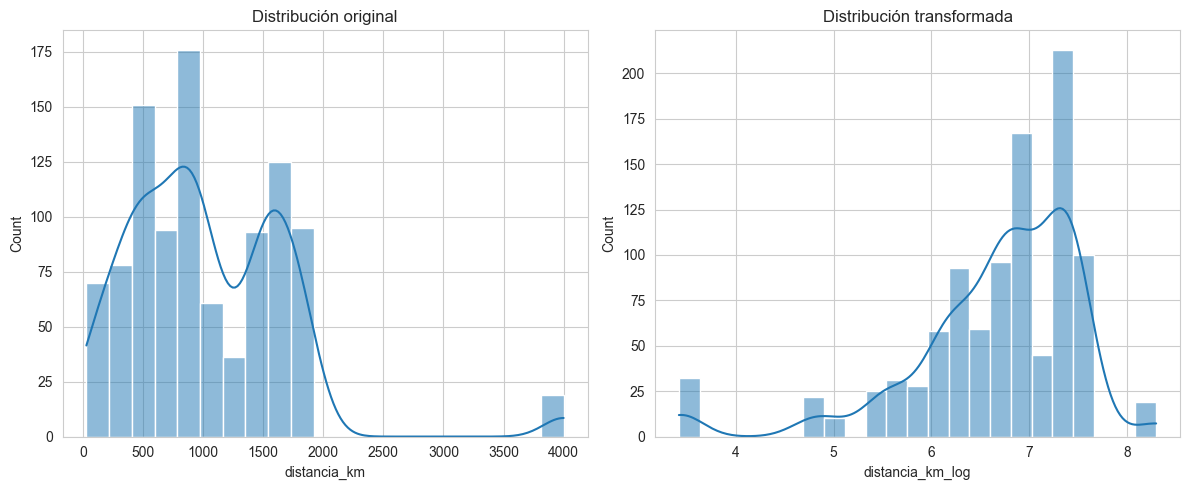

In [2]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(df["distancia_km"], kde=True)

plt.title("Distribución original")

plt.subplot(1,2,2)

sns.histplot(df["distancia_km_log"], kde=True)

plt.title("Distribución transformada")

plt.tight_layout()

plt.show()


# 🔎 Análisis

La transformación logarítmica permitió reducir la dispersión extrema y estabilizar la distribución de los datos.

Esto ayudó a mejorar el rendimiento de los modelos de Machine Learning.


# ⚙️ 4. Feature Engineering

Variables creadas más importantes:

- `uso_capacidad_kg_recalculado`
- `riesgo_velocidad`
- `vehiculo_exigido`
- `sobrecarga_kg`
- `ruta_larga`
- `velocidad_alta`

Estas variables permitieron representar mejor el comportamiento operacional real.


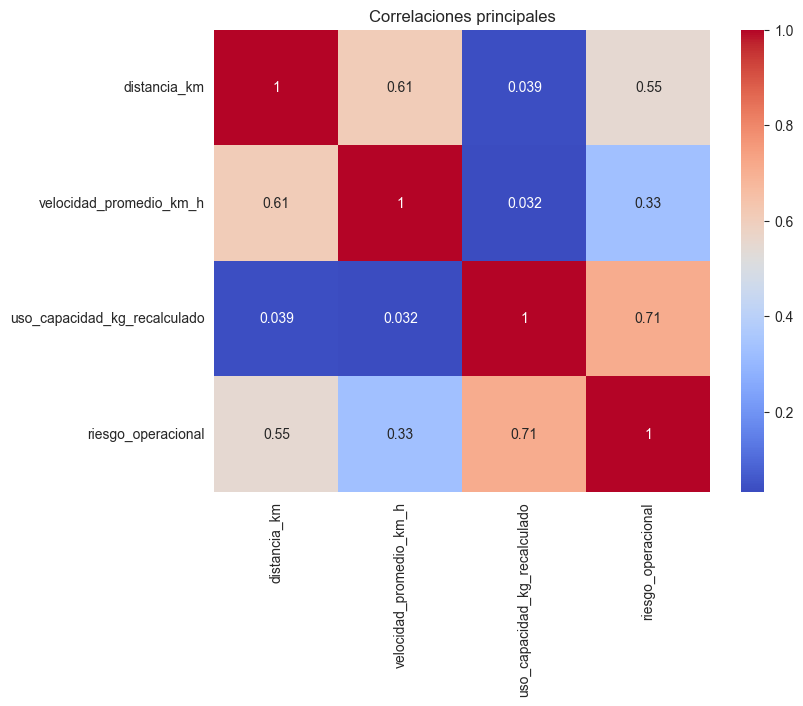

In [3]:
variables_importantes = [
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg_recalculado",
    "riesgo_operacional"
]

corr = df[variables_importantes].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlaciones principales")

plt.show()


# 📊 5. Análisis exploratorio de datos

Hallazgos principales:

- operaciones rápidas y extensas presentan mayor riesgo;
- sobrecarga y utilización de capacidad aumentan el riesgo operacional;
- el riesgo depende de múltiples variables combinadas.


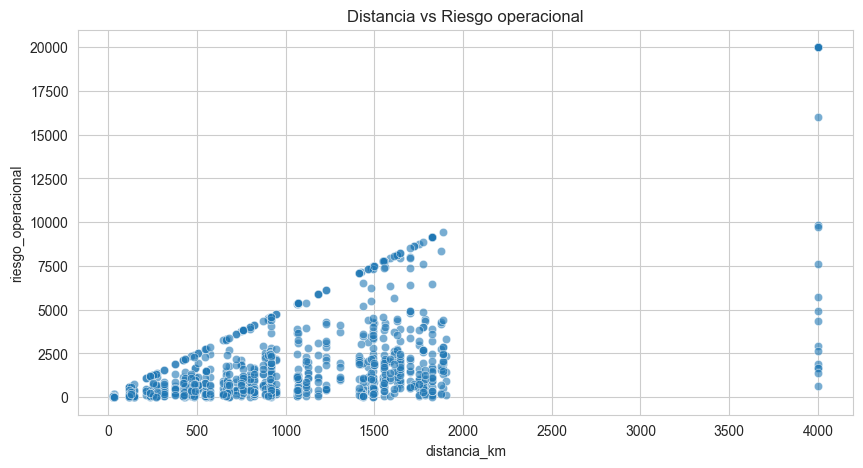

In [4]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="distancia_km",
    y="riesgo_operacional",
    alpha=0.6
)

plt.title("Distancia vs Riesgo operacional")

plt.show()


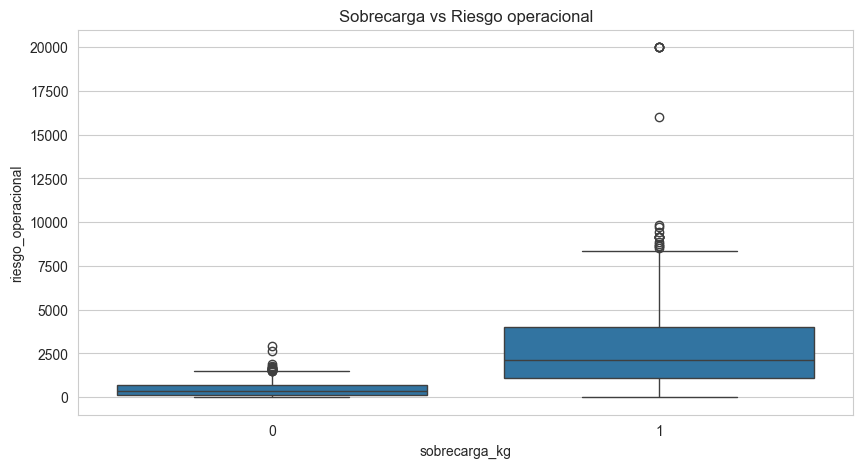

In [5]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="sobrecarga_kg",
    y="riesgo_operacional"
)

plt.title("Sobrecarga vs Riesgo operacional")

plt.show()


# 🎯 6. Selección de predicciones finales

Targets evaluados:

- `tiene_incidencia`
- `entrega_tardia`
- `entrega_tardia_v3`
- `incidencia_multiclase`
- `riesgo_operacional_alto`
- `riesgo_operacional`

---

## Targets finales

### Clasificación
`riesgo_operacional_alto`

### Regresión
`riesgo_operacional`


# 🤖 7. Modelos supervisados - Clasificación

Modelos probados:

- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- SVM
- GaussianNB


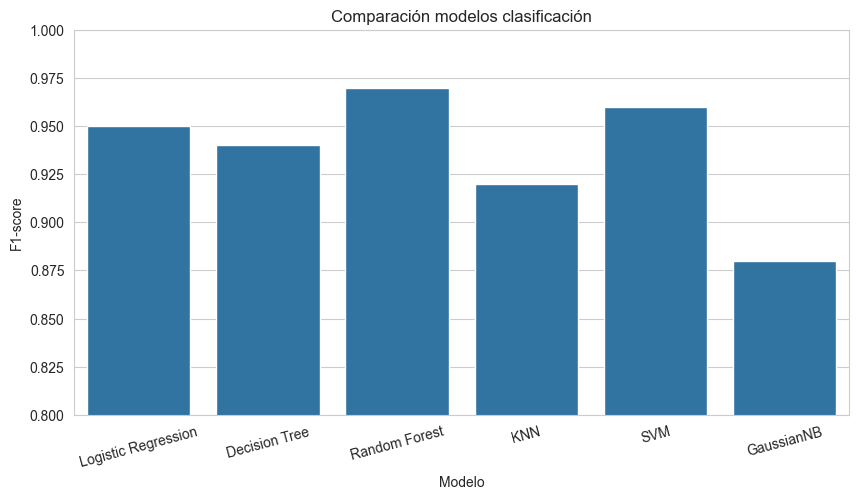

,Modelo,F1-score
0,Logistic Regression,0.9500
1,Decision Tree,0.9400
2,Random Forest,0.9697
3,KNN,0.9200
4,SVM,0.9600
5,GaussianNB,0.8800


In [6]:
resultados_clf = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "GaussianNB"
    ],
    "F1-score": [
        0.95,
        0.94,
        0.9697,
        0.92,
        0.96,
        0.88
    ]
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=resultados_clf,
    x="Modelo",
    y="F1-score"
)

plt.title("Comparación modelos clasificación")

plt.ylim(0.8,1)

plt.xticks(rotation=15)

plt.show()

resultados_clf


# 📌 Mejor modelo clasificación

# 🌲 Random Forest Classifier

| Métrica | Resultado |
|---|---|
| Accuracy | 0.985 |
| Balanced Accuracy | 0.983 |
| F1-score | 0.9697 |
| AUC ROC | ~0.998 |

El modelo logró identificar operaciones de alto riesgo con una precisión extremadamente alta.


# 📉 8. Modelos supervisados - Regresión

Modelos probados:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- KNN Regressor
- SVR


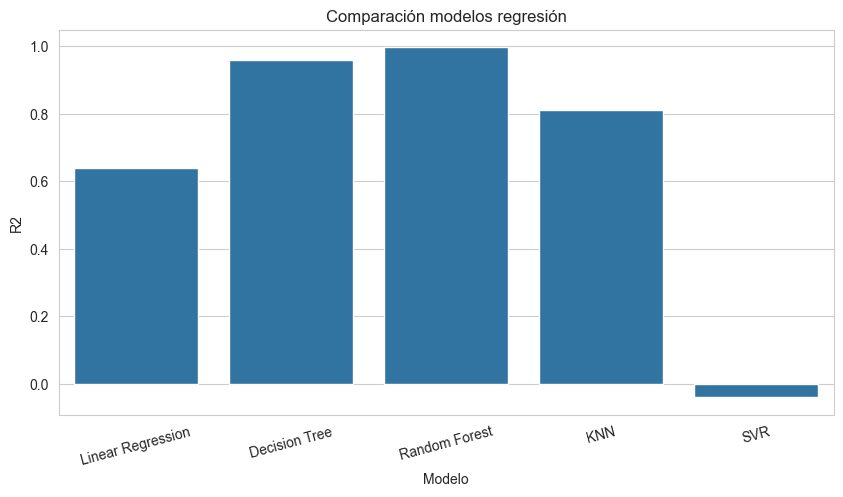

,Modelo,R2
0,Linear Regression,0.640
1,Decision Tree,0.960
2,Random Forest,0.996
3,KNN,0.810
4,SVR,-0.040


In [7]:
resultados_reg = pd.DataFrame({
    "Modelo": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR"
    ],
    "R2": [
        0.64,
        0.96,
        0.996,
        0.81,
        -0.04
    ]
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=resultados_reg,
    x="Modelo",
    y="R2"
)

plt.title("Comparación modelos regresión")

plt.xticks(rotation=15)

plt.show()

resultados_reg


# 📌 Mejor modelo regresión

# 🌲 Random Forest Regressor

| Métrica | Resultado |
|---|---|
| MAE | ~49 |
| RMSE | ~110 |
| R² | ~0.996 |

El modelo logró estimar el riesgo operacional con un error muy bajo.


# ⚡ 9. Optimización de hiperparámetros

Se utilizaron:

- GridSearchCV;
- validación cruzada;
- Optuna.

---

## Configuración final clasificación

```python
RandomForestClassifier(
    n_estimators=258,
    max_depth=13,
    min_samples_split=4,
    min_samples_leaf=2
)
```

---

## Configuración final regresión

```python
RandomForestRegressor(
    n_estimators=273,
    max_depth=14,
    min_samples_split=6,
    min_samples_leaf=1
)
```


# 🔥 10. Variables más importantes

Variables dominantes:

- uso_capacidad_kg_recalculado
- sobrecarga_kg
- vehiculo_exigido
- distancia_km
- riesgo_velocidad
- velocidad_promedio_km_h


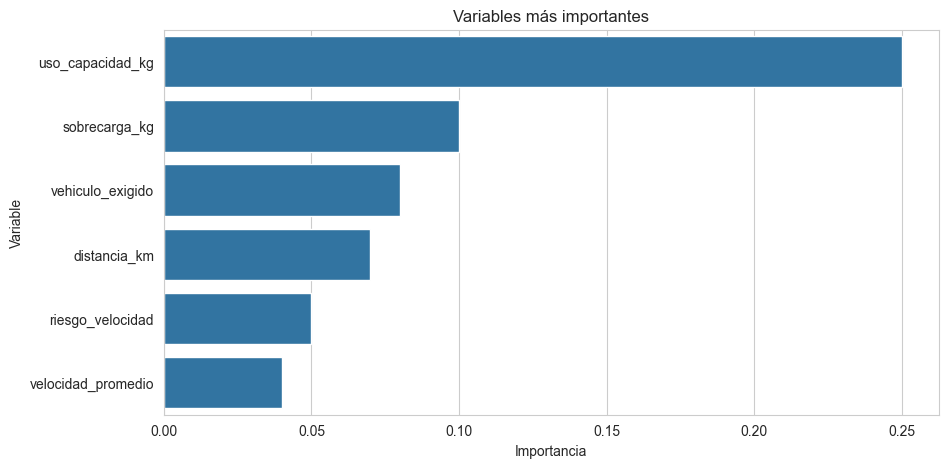

In [8]:
variables_top = pd.DataFrame({
    "Variable": [
        "uso_capacidad_kg",
        "sobrecarga_kg",
        "vehiculo_exigido",
        "distancia_km",
        "riesgo_velocidad",
        "velocidad_promedio"
    ],
    "Importancia": [
        0.25,
        0.10,
        0.08,
        0.07,
        0.05,
        0.04
    ]
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=variables_top,
    x="Importancia",
    y="Variable"
)

plt.title("Variables más importantes")

plt.show()


# 🧠 11. Aprendizaje no supervisado

Se aplicaron:

- PCA;
- KMeans;
- clustering logístico.

Objetivo:
identificar grupos naturales dentro de las operaciones logísticas.


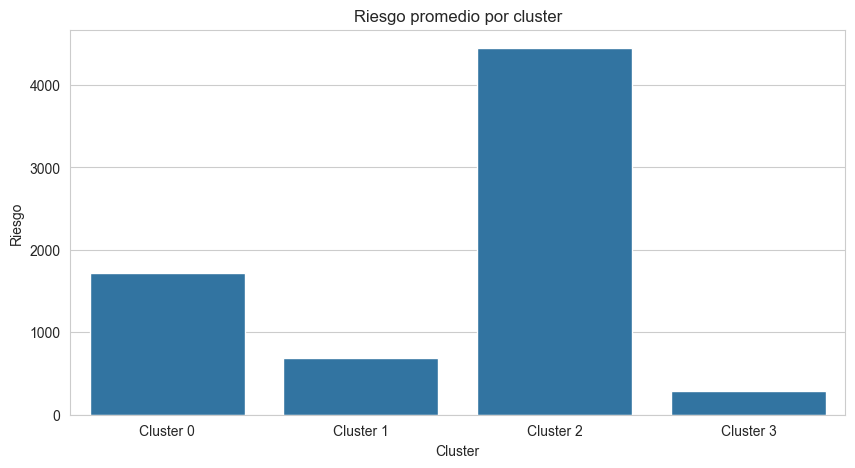

,Cluster,Riesgo
0,Cluster 0,1720
1,Cluster 1,688
2,Cluster 2,4448
3,Cluster 3,287


In [9]:
clusters = pd.DataFrame({
    "Cluster": ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"],
    "Riesgo": [1720, 688, 4448, 287]
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=clusters,
    x="Cluster",
    y="Riesgo"
)

plt.title("Riesgo promedio por cluster")

plt.show()

clusters


# 📌 Hallazgos del clustering

## Cluster 2
Operaciones críticas:
- alta velocidad;
- rutas largas;
- sobrecarga;
- vehículos exigidos.

---

## Cluster 3
Operaciones normales:
- bajo riesgo;
- baja velocidad;
- sin sobrecarga.

El clustering logró detectar operaciones críticas sin utilizar targets supervisados.


# 🚀 12. Impacto operacional

Los modelos podrían utilizarse para:

- detectar operaciones críticas;
- monitorear envíos;
- optimizar planificación;
- reducir riesgos operacionales.

---

## Resultado principal

El riesgo operacional surge de combinaciones complejas entre:

- velocidad;
- distancia;
- carga;
- utilización de capacidad;
- exigencia vehicular.


#  🟢13. Conclusiones finales

El proyecto logró desarrollar exitosamente un sistema de análisis y predicción de riesgo operacional logístico utilizando técnicas modernas de Machine Learning.

Los resultados demostraron que el riesgo operacional no depende de una sola variable, sino de combinaciones complejas entre:

- velocidad promedio;
- distancia recorrida;
- sobrecarga;
- utilización de capacidad;
- exigencia vehicular.

---

# 🎯 Hallazgos más relevantes

## 📈 El feature engineering fue fundamental

Las variables creadas permitieron representar de mejor manera el comportamiento operacional real.

Las más importantes fueron:

- `uso_capacidad_kg_recalculado`
- `sobrecarga_kg`
- `vehiculo_exigido`
- `riesgo_velocidad`
- `ruta_larga`

---

## 🤖 Random Forest fue el modelo más robusto

Tras comparar distintos modelos supervisados, los mejores resultados se obtuvieron utilizando:

### Clasificación
`Random Forest Classifier`

```python
RandomForestClassifier(
    n_estimators=258,
    max_depth=13,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)
```

### Regresión
`Random Forest Regressor`

```python
RandomForestRegressor(
    n_estimators=273,
    max_depth=14,
    min_samples_split=6,
    min_samples_leaf=1,
    random_state=42
)
```

## 📊 Resultados principales

| Modelo | Resultado destacado |
|---|---|
| Random Forest Classifier | AUC ≈ 0.998 |
| Random Forest Regressor | R² ≈ 0.996 |

Estos resultados demuestran una capacidad extremadamente alta para identificar y estimar operaciones críticas dentro de la logística.

---

## 🧠 El clustering confirmó patrones naturales

El aprendizaje no supervisado permitió identificar grupos asociados a:

- operaciones normales;
- rutas rápidas;
- operaciones pesadas;
- operaciones críticas de alto riesgo.

Esto confirmó la coherencia y calidad del dataset construido.

---

# 🚀 Conclusión general

El proyecto demostró que Machine Learning puede utilizarse para anticipar riesgos operacionales, detectar patrones críticos y transformar datos logísticos en información estratégica para mejorar la toma de decisiones.